# Análisis de los datasets disponibles

Este notebook recorre los datasets candidatos para el TFG de predicción de
estadísticas NBA y comparativa con cuotas de casas de apuestas. La idea es
saber cuál cubre qué temporadas, cuán fiables son las cuotas, y qué
información estadística podemos enriquecer con la API oficial de la NBA.

In [ ]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from nba_api.stats.endpoints import LeagueGameLog

df1   = pd.read_csv("datasets/kaggle/dataset1.csv");   print(f"✅ Cargado dataset1.csv ({len(df1)} filas)")
df2   = pd.read_csv("datasets/kaggle/dataset2.csv");   print(f"✅ Cargado dataset2.csv ({len(df2)} filas)")
df3_1 = pd.read_csv("datasets/kaggle/dataset3_1.csv"); print(f"✅ Cargado dataset3_1.csv ({len(df3_1)} filas)")
df3_2 = pd.read_csv("datasets/kaggle/dataset3_2.csv"); print(f"✅ Cargado dataset3_2.csv ({len(df3_2)} filas)")
df3_3 = pd.read_csv("datasets/kaggle/dataset3_3.csv"); print(f"✅ Cargado dataset3_3.csv ({len(df3_3)} filas)")
df4   = pd.read_csv("datasets/kaggle/dataset4.csv");   print(f"✅ Cargado dataset4.csv ({len(df4)} filas)")
df5   = pd.read_csv("datasets/dataset5.csv");   print(f"✅ Cargado dataset5.csv ({len(df5)} filas)")

print("\nDF1:   ", df1.columns.tolist())
print("DF2:   ", df2.columns.tolist()) # ODDS FINAL
print("DF3_1: ", df3_1.columns.tolist())
print("DF3_2: ", df3_2.columns.tolist())
print("DF3_3: ", df3_3.columns.tolist())
print("DF4:   ", df4.columns.tolist())
print("DF5:   ", df5.columns.tolist())

pd.set_option('display.max_columns', None)

✅ Cargado dataset1.csv (37104 filas)
✅ Cargado dataset2.csv (23118 filas)
✅ Cargado dataset3_1.csv (125286 filas)
✅ Cargado dataset3_2.csv (131690 filas)
✅ Cargado dataset3_3.csv (131386 filas)
✅ Cargado dataset4.csv (146742 filas)
✅ Cargado dataset5.csv (21336 filas)

DF1:    ['date', 'season', 'team', 'home/visitor', 'opponent', 'score', 'opponentScore', 'moneyLine', 'opponentMoneyLine', 'total', 'spread', 'secondHalfTotal']
DF2:    ['season', 'date', 'regular', 'playoffs', 'away', 'home', 'score_away', 'score_home', 'q1_away', 'q2_away', 'q3_away', 'q4_away', 'ot_away', 'q1_home', 'q2_home', 'q3_home', 'q4_home', 'ot_home', 'whos_favored', 'spread', 'total', 'moneyline_away', 'moneyline_home', 'h2_spread', 'h2_total', 'id_spread', 'id_total']
DF3_1:  ['game_id', 'book_name', 'book_id', 'team_id', 'a_team_id', 'price1', 'price2']
DF3_2:  ['game_id', 'book_name', 'book_id', 'team_id', 'a_team_id', 'spread1', 'spread2', 'price1', 'price2']
DF3_3:  ['game_id', 'book_name', 'book_id', 't

## Cobertura de partidos por temporada

Cada dataset tiene su propia forma de identificar partidos (filas duplicadas
home/away, `game_id` codificado, marcas temporales por mercado…). Se
normaliza todo a partidos únicos por temporada NBA (octubre → junio) para
poder compararlos en igualdad de condiciones.

In [3]:
# Helper: temporada NBA a partir de una fecha (oct → jun)
def season_from_date(s):
    s = pd.to_datetime(s)
    y = s.dt.year.where(s.dt.month >= 10, s.dt.year - 1)
    return y.astype(str) + '-' + (y + 1).astype(str).str[-2:]

# Helper: temporada NBA a partir de game_id de stats.nba.com (10 dígitos)
# Formato: 00 + tipo(1d) + año(2d) + nº partido(5d)
def season_from_gameid(gid):
    s = str(int(gid)).zfill(10)
    yy = int(s[3:5])
    yyyy = 2000 + yy if yy < 50 else 1900 + yy
    return f"{yyyy}-{str(yyyy + 1)[-2:]}"

# DF1 (christophertreasure): col 'season' = año final, 2 filas por partido
n1 = (df1.groupby('season').size() // 2).rename('df1_christ')
n1.index = [f"{s-1}-{str(s)[-2:]}" for s in n1.index]

# DF2: col 'season' = año final, 1 fila por partido
n2 = df2.groupby('season').size().rename('df2_secondary')
n2.index = [f"{s-1}-{str(s)[-2:]}" for s in n2.index]

# DF3_1/2/3 (ehallmar): temporada derivada de game_id, contar partidos únicos
n3_1 = (df3_1.assign(season=df3_1['game_id'].apply(season_from_gameid))
              .groupby('season')['game_id'].nunique().rename('df3_1_ML'))
n3_2 = (df3_2.assign(season=df3_2['game_id'].apply(season_from_gameid))
              .groupby('season')['game_id'].nunique().rename('df3_2_Spread'))
n3_3 = (df3_3.assign(season=df3_3['game_id'].apply(season_from_gameid))
              .groupby('season')['game_id'].nunique().rename('df3_3_Totals'))

# DF4 (markets recientes): muchas filas por partido → contar (fecha, matchup) únicos
df4_tmp = df4.assign(
    date=pd.to_datetime(df4['timestamp']).dt.date,
    season=season_from_date(df4['timestamp']),
)
n4 = (df4_tmp.drop_duplicates(['date', 'matchup'])
              .groupby('season').size().rename('df4_recent'))

# DF5 (full_dataset_clean): match_date directo, 1 fila por partido
n5 = (df5.assign(season=season_from_date(df5['match_date']))
          .groupby('season')['match_id'].nunique().rename('df5_features'))

# Tabla resumen alineada por temporada
resumen = (pd.concat([n1, n2, n3_1, n3_2, n3_3, n4, n5], axis=1)
             .fillna(0).astype(int).sort_index())

print("Total partidos por dataset:")
for col in resumen.columns:
    print(f"  {col:20s} {resumen[col].sum():>7,}")
print()
print(resumen.to_string())

Total partidos por dataset:
  df1_christ            18,552
  df2_secondary         23,118
  df3_1_ML              14,906
  df3_2_Spread          14,914
  df3_3_Totals          14,918
  df4_recent             1,251
  df5_features          21,336

         df1_christ  df2_secondary  df3_1_ML  df3_2_Spread  df3_3_Totals  df4_recent  df5_features
2006-07           0              0      1204          1203          1203           0             0
2007-08        1230           1316      1221          1221          1221           0          1098
2008-09        1230           1315      1269          1269          1271           0          1230
2009-10        1230           1312      1269          1269          1269           0          1229
2010-11        1230           1311      1213          1215          1213           0          1217
2011-12         990           1074      1104          1104          1104           0           973
2012-13        1229           1314      1302          1302   

## Visualización: líneas y barras

La línea muestra la evolución temporal de la cobertura. Las dos referencias
horizontales son la temporada regular completa (1230) y la regular más
playoffs (≈1311). El gráfico de barras agrupadas debajo muestra lo mismo
en términos absolutos por temporada, útil cuando interesa el dato exacto
más que la tendencia.

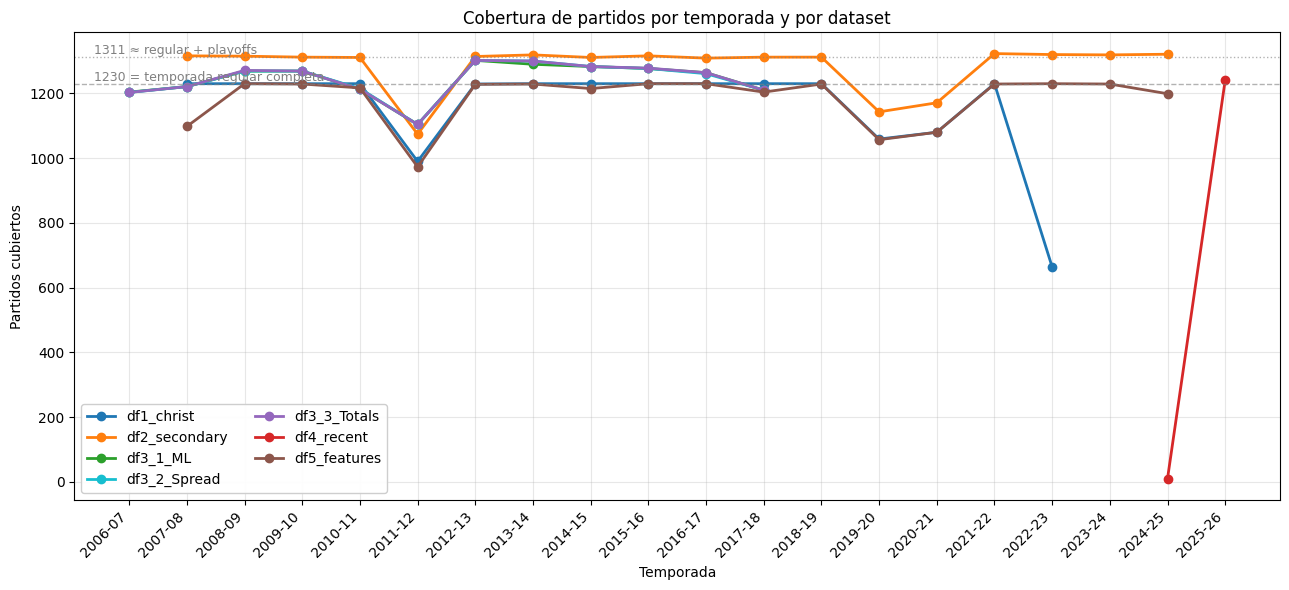

In [4]:
fig, ax = plt.subplots(figsize=(13, 6))

colors = {
    'df1_christ':    '#1f77b4',
    'df2_secondary': '#ff7f0e',
    'df3_1_ML':      '#2ca02c',
    'df3_2_Spread':  '#17becf',
    'df3_3_Totals':  '#9467bd',
    'df4_recent':    '#d62728',
    'df5_features':  '#8c564b',
}

for col in resumen.columns:
    serie = resumen[col].astype(float).replace(0, np.nan)  # ocultar ceros sin romper el plot
    ax.plot(resumen.index, serie, marker='o', linewidth=2,
            label=col, color=colors.get(col))

# Líneas de referencia
ax.axhline(1230, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.text(0.01, 1230, '  1230 = temporada regular completa',
        transform=ax.get_yaxis_transform(), va='bottom', fontsize=9, color='gray')
ax.axhline(1311, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax.text(0.01, 1311, '  1311 ≈ regular + playoffs',
        transform=ax.get_yaxis_transform(), va='bottom', fontsize=9, color='gray')

ax.set_xlabel('Temporada')
ax.set_ylabel('Partidos cubiertos')
ax.set_title('Cobertura de partidos por temporada y por dataset')
ax.set_xticks(range(len(resumen.index)))
ax.set_xticklabels(resumen.index, rotation=45, ha='right')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower left', ncol=2, framealpha=0.95)

plt.tight_layout()
plt.show()

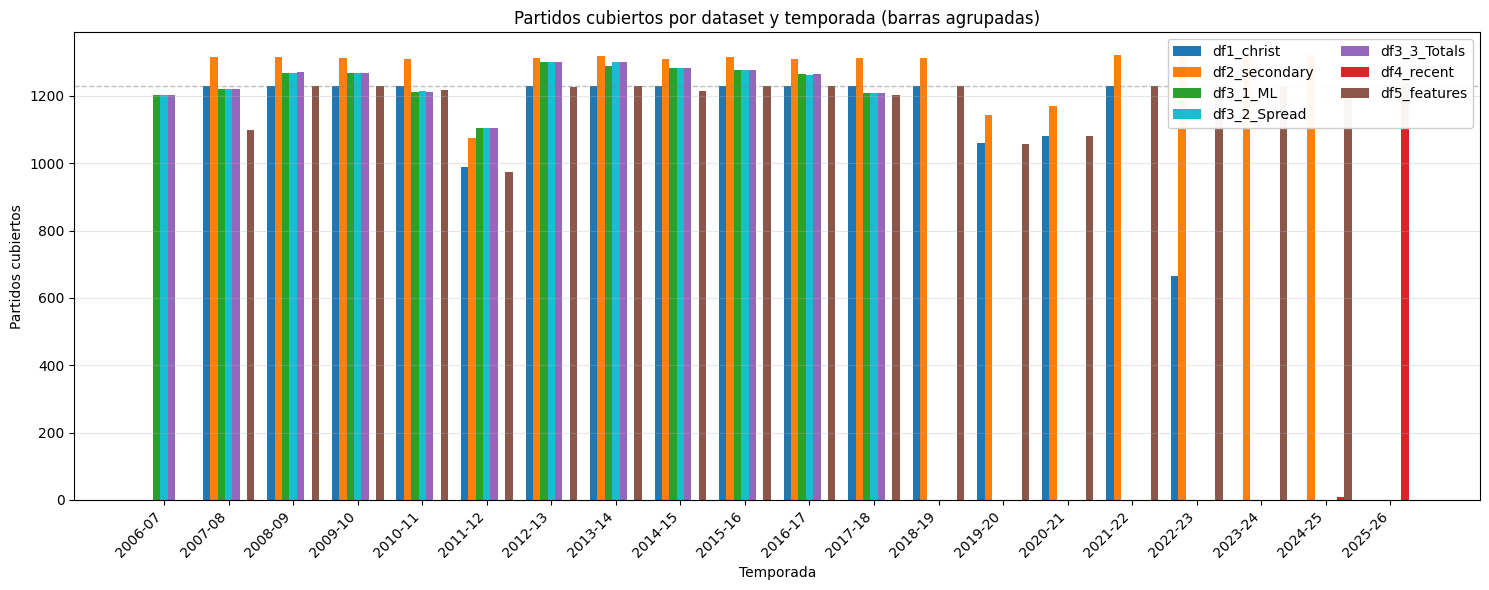

In [5]:
# Gráfico de barras agrupadas con los partidos cubiertos por dataset y temporada
fig, ax = plt.subplots(figsize=(15, 6))

n_datasets = len(resumen.columns)
n_seasons  = len(resumen.index)
bar_width  = 0.8 / n_datasets
x          = np.arange(n_seasons)

for i, col in enumerate(resumen.columns):
    offset = (i - (n_datasets - 1) / 2) * bar_width
    ax.bar(x + offset, resumen[col].values, width=bar_width,
           label=col, color=colors.get(col))

ax.axhline(1230, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Temporada')
ax.set_ylabel('Partidos cubiertos')
ax.set_title('Partidos cubiertos por dataset y temporada (barras agrupadas)')
ax.set_xticks(x)
ax.set_xticklabels(resumen.index, rotation=45, ha='right')
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='upper right', ncol=2, framealpha=0.95)

plt.tight_layout()
plt.show()

## ¿Discrepan las casas de apuestas en df3?

`df3_1` (moneyline), `df3_2` (spread) y `df3_3` (totals) traen la cuota de
varias casas para cada partido. Si todas marcan prácticamente lo mismo,
mantener varias columnas no aporta nada al modelo. La idea es medir, por
mercado, cuánto varía el precio entre casas para un mismo partido.

In [6]:
# Limpiar df3_2 (Spread): precios de spread plausibles entre -200 y +200
df3_2_clean = df3_2[df3_2['price1'].between(-200, 200) &
                    df3_2['price2'].between(-200, 200)].copy()

# Para spread1: si una casa difiere >3 puntos de la mediana del partido, fuera
median_spread = df3_2_clean.groupby('game_id')['spread1'].transform('median')
df3_2_clean = df3_2_clean[(df3_2_clean['spread1'] - median_spread).abs() <= 3]

# df3_3 (Total): precios igual que arriba, y total entre 150 y 260
df3_3_clean = df3_3[df3_3['price1'].between(-200, 200) &
                    df3_3['total1'].between(150, 260)].copy()
# Limpieza extra para totals: descartar filas que se desvían >10 de la mediana del partido
median_total = df3_3_clean.groupby('game_id')['total1'].transform('median')
df3_3_clean = df3_3_clean[(df3_3_clean['total1'] - median_total).abs() <= 10]
print(f"Totals tras filtro extra: {len(df3_3_clean):,} filas")

# Limpieza más robusta de df3_1 (Moneyline)
df3_1_clean = df3_1[df3_1['price1'].between(-50000, 50000) &
                    df3_1['price2'].between(-50000, 50000)].copy()

# Filtrar outliers por desviación relativa de la mediana del partido
for col in ['price1', 'price2']:
    med  = df3_1_clean.groupby('game_id')[col].transform('median')
    diff = (df3_1_clean[col] - med).abs()
    # Margen tolerado: 50% de la mediana (en valor absoluto), mínimo 100 cents
    tol  = (med.abs() * 0.5).clip(lower=100)
    df3_1_clean = df3_1_clean[diff <= tol]

print(f"Moneyline: {len(df3_1):,} → {len(df3_1_clean):,} filas tras limpieza fina")

Totals tras filtro extra: 131,207 filas
Moneyline: 125,286 → 123,068 filas tras limpieza fina


=== Moneyline (df3_1) ===
  Casas presentes: 10
  Top 10 casas por nº de cotizaciones:
    5Dimes                          14,894
    Pinnacle Sports                 14,822
    Bookmaker                       14,785
    JustBet                         13,604
    Sportsbetting                   12,953
    BetOnline                       12,953
    Intertops                       11,886
    Bovada                          11,013
    YouWager                         9,681
    Heritage                         8,695

  Discrepancia entre casas (partidos con ≥2 casas):
          n_partidos  media_global  std_media  rango_medio  rango_p95
variable                                                             
price1         14905       149.657     25.913       68.676      240.0
price2         14905      -266.072     37.059       96.723      300.0

=== Spread (df3_2) ===
  Casas presentes: 10
  Top 10 casas por nº de cotizaciones:
    5Dimes                          14,904
    Bovada            

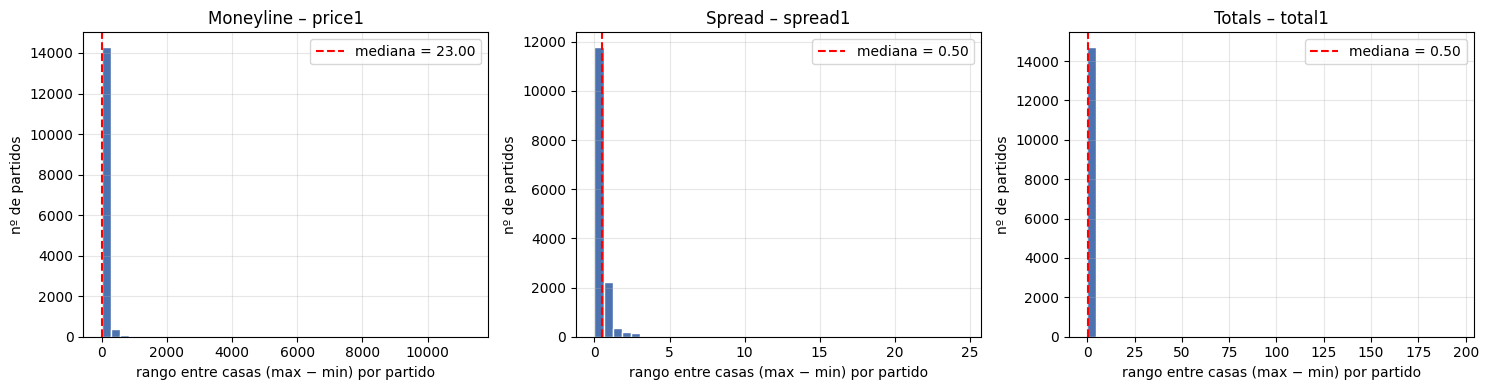

Lectura rápida:
  · Si la mediana del rango ≈ 0 → las casas dicen casi lo mismo y no compensa cruzarlas.
  · Si el rango_p95 es alto → en una minoría de partidos hay diferencias jugosas.


In [7]:
def discrepancia_casas(df, value_cols, nombre_mercado):
    """Mide cuánto varían las cuotas entre casas para el mismo partido."""
    print(f"=== {nombre_mercado} ===")
    print(f"  Casas presentes: {df['book_name'].nunique()}")
    print(f"  Top 10 casas por nº de cotizaciones:")
    top_books = df['book_name'].value_counts().head(10)
    for book, cnt in top_books.items():
        print(f"    {book:30s} {cnt:>7,}")

    # Para cada columna de cuota: por partido, std y rango entre casas
    stats = []
    for col in value_cols:
        gp = df.groupby('game_id')[col]
        # Solo partidos con al menos 2 casas
        mask = gp.transform('count') >= 2
        gp = df.loc[mask].groupby('game_id')[col]
        s = pd.DataFrame({
            'media':  gp.mean(),
            'std':    gp.std(),
            'rango':  gp.max() - gp.min(),
            'n_casas': gp.count(),
        })
        s['variable'] = col
        stats.append(s)
    stats = pd.concat(stats)

    print(f"\n  Discrepancia entre casas (partidos con ≥2 casas):")
    resumen_disc = stats.groupby('variable').agg(
        n_partidos=('media', 'size'),
        media_global=('media', 'mean'),
        std_media=('std', 'mean'),
        rango_medio=('rango', 'mean'),
        rango_p95=('rango', lambda x: x.quantile(0.95)),
    ).round(3)
    print(resumen_disc.to_string())
    print()
    return stats

stats_ml     = discrepancia_casas(df3_1, ['price1', 'price2'],            'Moneyline (df3_1)')
stats_spread = discrepancia_casas(df3_2, ['spread1', 'price1'],           'Spread (df3_2)')
stats_total  = discrepancia_casas(df3_3, ['total1', 'price1'],            'Totals (df3_3)')

# Visualización: distribución del rango entre casas para cada mercado
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (stats, etiqueta, var_principal) in zip(
    axes,
    [(stats_ml,     'Moneyline – price1', 'price1'),
     (stats_spread, 'Spread – spread1',   'spread1'),
     (stats_total,  'Totals – total1',    'total1')],
):
    valores = stats.loc[stats['variable'] == var_principal, 'rango'].dropna()
    ax.hist(valores, bins=40, color='#4c72b0', edgecolor='white')
    ax.axvline(valores.median(), color='red', linestyle='--',
               label=f'mediana = {valores.median():.2f}')
    ax.set_title(etiqueta)
    ax.set_xlabel('rango entre casas (max − min) por partido')
    ax.set_ylabel('nº de partidos')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Conclusión rápida en consola
print("Lectura rápida:")
print("  · Si la mediana del rango ≈ 0 → las casas dicen casi lo mismo y no compensa cruzarlas.")
print("  · Si el rango_p95 es alto → en una minoría de partidos hay diferencias jugosas.")

In [8]:


print(f"Spread:    {len(df3_2):,} → {len(df3_2_clean):,} filas tras limpieza")
print(f"Totals:    {len(df3_3):,} → {len(df3_3_clean):,} filas tras limpieza")
print(f"Moneyline: {len(df3_1):,} → {len(df3_1_clean):,} filas tras limpieza")

def top_discrepancias(df, line_col, price_col, nombre, k=10, k_detalle=3):
    """Saca los top-k partidos por rango entre casas en la línea y en el precio."""
    base = df.groupby('game_id').size()
    multi = base[base >= 2].index  # solo partidos con ≥2 casas

    # 1) Discrepancia en la LÍNEA
    lin = (df[df['game_id'].isin(multi)]
           .groupby('game_id')[line_col]
           .agg(min='min', max='max', mean='mean', std='std', n='count'))
    lin['rango'] = (lin['max'] - lin['min']).round(3)
    top_lin = lin.sort_values('rango', ascending=False).head(k)

    # 2) Discrepancia en el PRECIO
    pre = (df[df['game_id'].isin(multi)]
           .groupby('game_id')[price_col]
           .agg(min='min', max='max', mean='mean', std='std', n='count'))
    pre['rango'] = (pre['max'] - pre['min']).round(3)
    top_pre = pre.sort_values('rango', ascending=False).head(k)

    print(f"{'='*70}")
    print(f"  {nombre}")
    print(f"{'='*70}")

    print(f"\n  TOP {k} partidos por discrepancia en LÍNEA ({line_col}):")
    print(top_lin[['n', 'min', 'max', 'rango', 'std']].round(2).to_string())

    print(f"\n  Detalle por casa de los {k_detalle} primeros:")
    cols_show = []
    for c in ['book_name', line_col, price_col, 'price2']:
        if c in df.columns and c not in cols_show:
            cols_show.append(c)
    for gid in top_lin.head(k_detalle).index:
        print(f"\n  · game_id = {gid}")
        sub = df[df['game_id'] == gid][cols_show].sort_values(line_col)
        print(sub.to_string(index=False))

    print(f"\n  TOP {k} partidos por discrepancia en PRECIO ({price_col}):")
    print(top_pre[['n', 'min', 'max', 'rango', 'std']].round(2).to_string())

    print(f"\n  Detalle por casa de los {k_detalle} primeros:")
    for gid in top_pre.head(k_detalle).index:
        print(f"\n  · game_id = {gid}")
        sub = df[df['game_id'] == gid][cols_show].sort_values(price_col)
        print(sub.to_string(index=False))
    print()
    return top_lin, top_pre


top_lin_sp, top_pre_sp = top_discrepancias(df3_2_clean, 'spread1', 'price1', 'SPREAD (df3_2)')
top_lin_ml, top_pre_ml = top_discrepancias(df3_1_clean, 'price1',  'price2', 'MONEYLINE (df3_1)  — aquí ambas son precios')
top_lin_tt, top_pre_tt = top_discrepancias(df3_3_clean, 'total1',  'price1', 'TOTALS (df3_3)')

Spread:    131,690 → 131,484 filas tras limpieza
Totals:    131,386 → 131,207 filas tras limpieza
Moneyline: 125,286 → 123,068 filas tras limpieza
  SPREAD (df3_2)

  TOP 10 partidos por discrepancia en LÍNEA (spread1):
           n  min  max  rango   std
game_id                            
20600911   4 -3.5  1.5    5.0  2.04
20600913   3  4.5  9.0    4.5  2.60
20800051   8 -3.5  0.0    3.5  1.07
20800042   8 -3.5  0.0    3.5  1.16
41300305  10 -2.0  1.5    3.5  1.20
21600057  10 -7.0 -3.5    3.5  1.01
21500084  10 -4.5 -1.0    3.5  1.05
20600948   4 -3.5  0.0    3.5  1.65
20600909   4 -3.5  0.0    3.5  1.70
21400581  10  2.0  5.5    3.5  0.98

  Detalle por casa de los 3 primeros:

  · game_id = 20600911
      book_name  spread1  price1  price2
         Bovada     -3.5  -110.0  -110.0
         5Dimes     -1.0  -110.0  -110.0
      Bookmaker     -1.0  -110.0  -110.0
Pinnacle Sports      1.5  -102.0  -108.0

  · game_id = 20600913
      book_name  spread1  price1  price2
Pinnacle Sports

## Estadísticas históricas vía NBA API

Para tener una referencia limpia (independiente de los datasets externos),
se descargan partidos directamente de `stats.nba.com` con `nba_api`. Cada
fila del endpoint `LeagueGameLog` es un equipo en un partido, así que
la media por temporada equivale a estadísticas por equipo y partido.

In [9]:
# Descargar logs de partidos de varias temporadas vía nba_api
SEASONS = ['2015-16', '2016-17', '2017-18', '2018-19', '2019-20',
           '2020-21', '2021-22', '2022-23', '2023-24', '2024-25']

# Descargar logs de partidos de TODAS las temporadas vía nba_api
# La NBA arranca en 1946-47. El triple se introduce en 1979-80.
def make_seasons(start_year=1946, end_year=2024):
    return [f"{y}-{str(y+1)[-2:]}" for y in range(start_year, end_year + 1)]

SEASONS = make_seasons(1946, 2024)
print(f"Voy a descargar {len(SEASONS)} temporadas (puede tardar 1-2 minutos).\n")

frames = []
for season in SEASONS:
    try:
        log = LeagueGameLog(season=season,
                            season_type_all_star='Regular Season',
                            timeout=30).get_data_frames()[0]
        log['SEASON'] = season
        frames.append(log)
        print(f"  {season}: {len(log)} filas")
        time.sleep(0.6)  # cortesía con la API
    except Exception as e:
        print(f"  {season}: error → {e}")

nba_logs = pd.concat(frames, ignore_index=True)
print(f"\nTotal filas: {len(nba_logs):,}")
print(f"Columnas relevantes: {[c for c in ['SEASON','TEAM_ABBREVIATION','PTS','FG3A','FG3M'] if c in nba_logs.columns]}")
nba_logs.head()

Voy a descargar 79 temporadas (puede tardar 1-2 minutos).

  1946-47: 662 filas
  1947-48: 388 filas
  1948-49: 720 filas
  1949-50: 1126 filas
  1950-51: 708 filas
  1951-52: 660 filas
  1952-53: 702 filas
  1953-54: 646 filas
  1954-55: 576 filas
  1955-56: 580 filas
  1956-57: 580 filas
  1957-58: 576 filas
  1958-59: 576 filas
  1959-60: 600 filas
  1960-61: 632 filas
  1961-62: 720 filas
  1962-63: 720 filas
  1963-64: 720 filas
  1964-65: 720 filas
  1965-66: 720 filas
  1966-67: 810 filas
  1967-68: 984 filas
  1968-69: 1148 filas
  1969-70: 1148 filas
  1970-71: 1394 filas
  1971-72: 1394 filas
  1972-73: 1394 filas
  1973-74: 1394 filas
  1974-75: 1476 filas
  1975-76: 1476 filas
  1976-77: 1804 filas
  1977-78: 1804 filas
  1978-79: 1804 filas
  1979-80: 1804 filas
  1980-81: 1886 filas
  1981-82: 1886 filas
  1982-83: 1886 filas
  1983-84: 1886 filas
  1984-85: 1886 filas
  1985-86: 1886 filas
  1986-87: 1886 filas
  1987-88: 1886 filas
  1988-89: 2050 filas
  1989-90: 2214 

C:\Users\ignac\AppData\Local\Temp\ipykernel_22636\804134351.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  nba_logs = pd.concat(frames, ignore_index=True)



Total filas: 134,600
Columnas relevantes: ['SEASON', 'TEAM_ABBREVIATION', 'PTS', 'FG3A', 'FG3M']


,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE,SEASON
0,21946,1610612752,NYK,New York Knicks,0024600001,1946-11-01,NYK @ HUS,W,0,24.0,NaN,NaN,NaN,NaN,NaN,20.0,26.0,0.769,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68,2,0,1946-47
1,21946,1610610035,HUS,Toronto Huskies,0024600001,1946-11-01,HUS vs. NYK,L,0,25.0,NaN,NaN,NaN,NaN,NaN,16.0,29.0,0.552,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66,-2,0,1946-47
2,21946,1610610028,DEF,Detroit Falcons,0024600005,1946-11-02,DEF vs. WAS,L,0,10.0,NaN,NaN,NaN,NaN,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33,-17,0,1946-47
3,21946,1610610036,WAS,Washington Capitols,0024600005,1946-11-02,WAS @ DEF,W,0,18.0,NaN,NaN,NaN,NaN,NaN,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50,17,0,1946-47
4,21946,1610612752,NYK,New York Knicks,0024600004,1946-11-02,NYK @ CHS,L,0,16.0,NaN,NaN,NaN,NaN,NaN,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.0,47,-16,0,1946-47


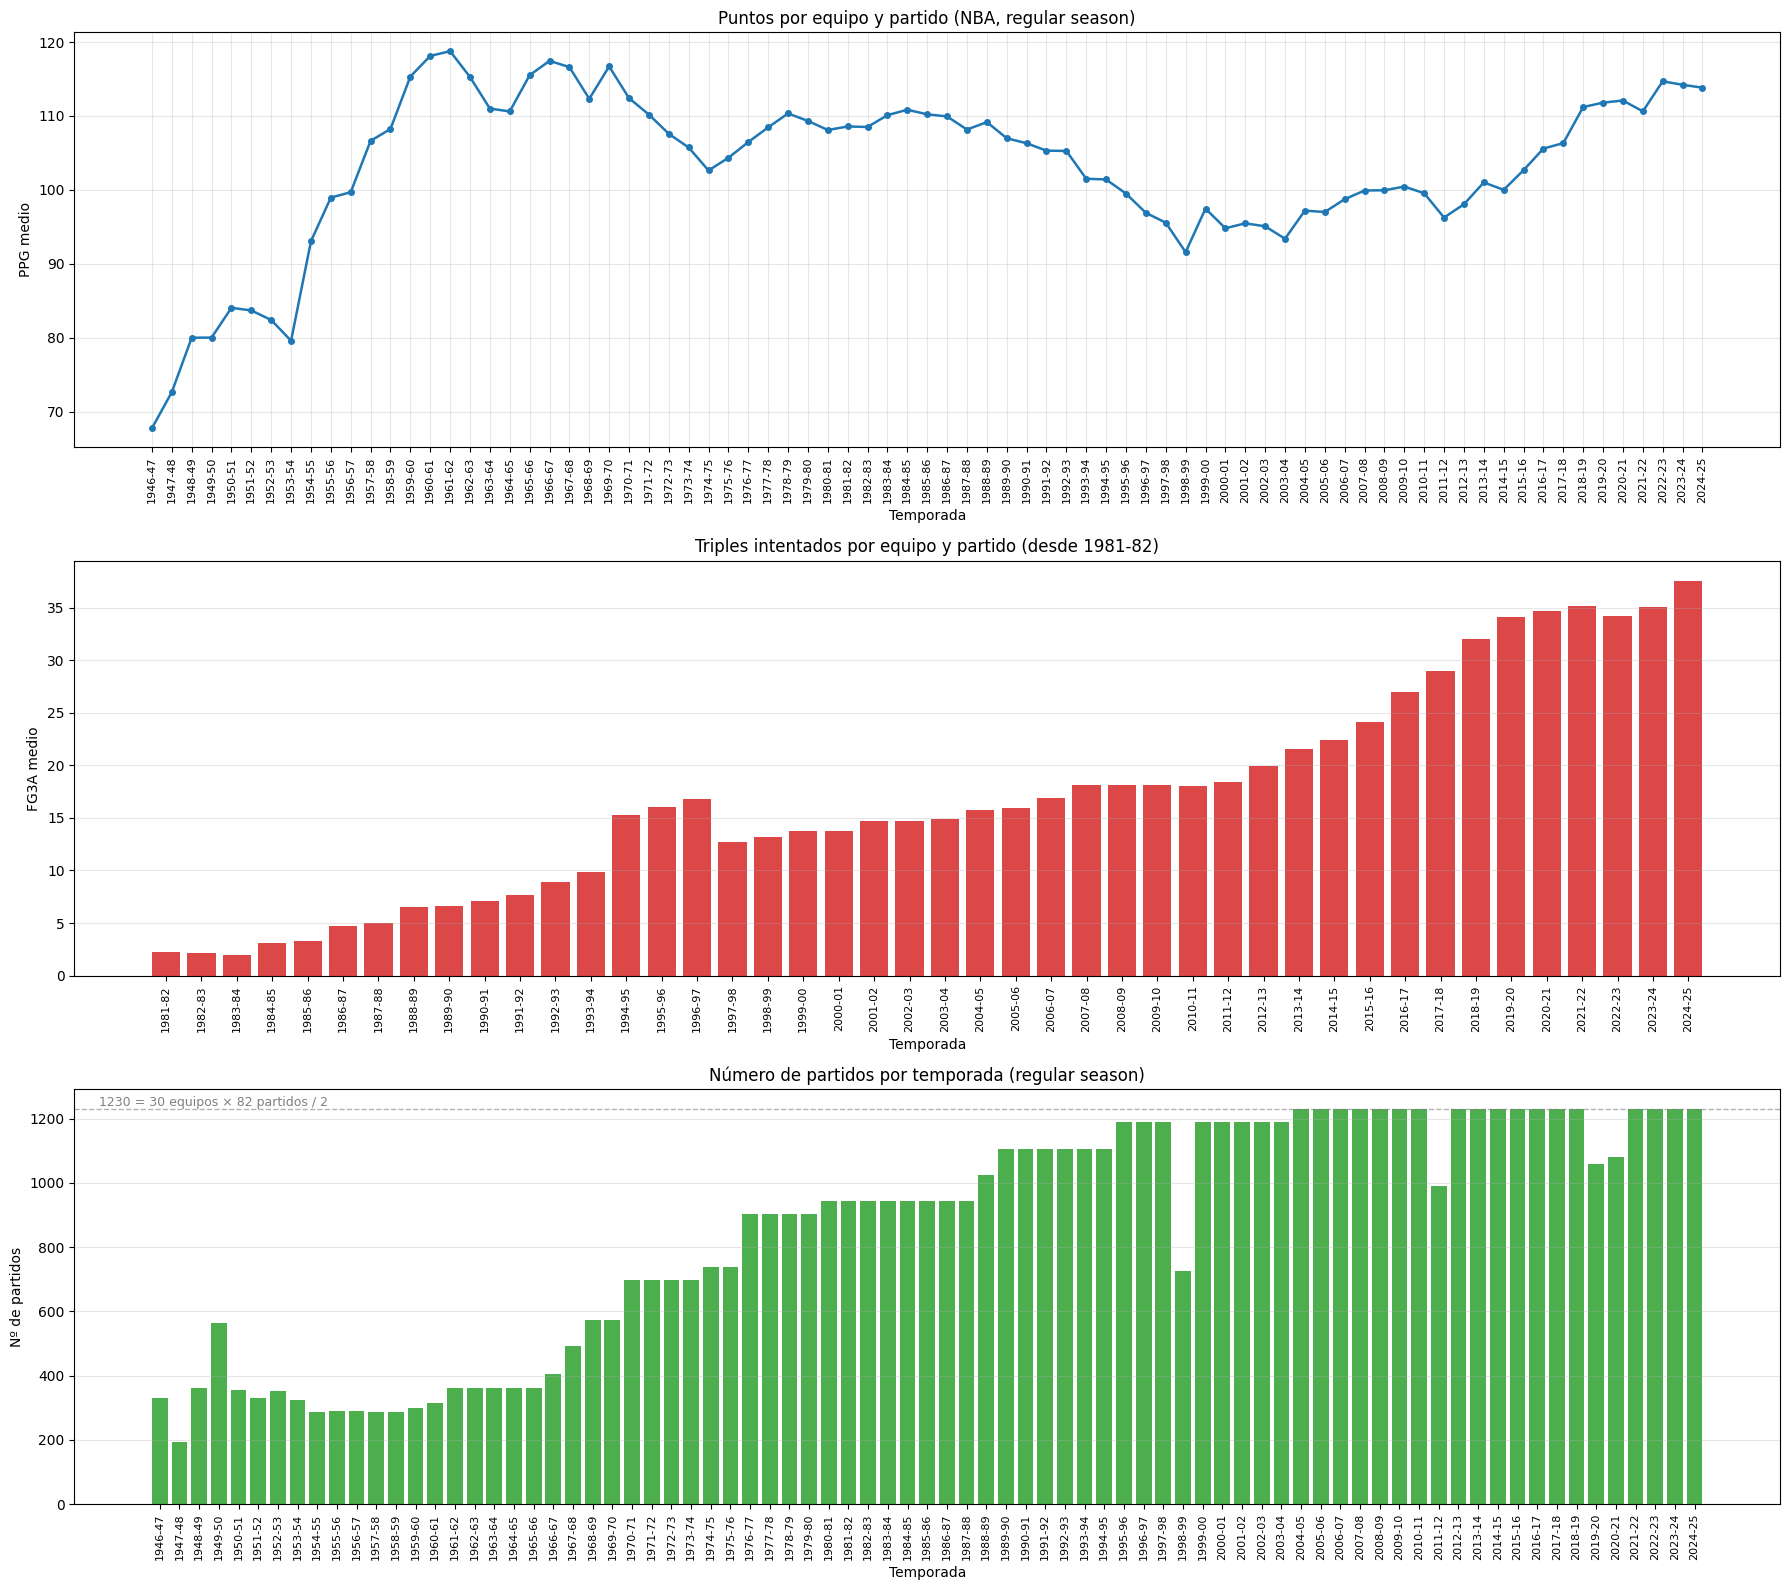

In [10]:
# Métricas por temporada: PPG, triples intentados y nº de partidos
season_stats = (nba_logs.groupby('SEASON')
                        .agg(ppg=('PTS',  'mean'),
                             fg3a=('FG3A', 'mean'),
                             fg3m=('FG3M', 'mean'),
                             n_partidos=('GAME_ID', 'nunique'),
                             n_filas=('PTS', 'size'))
                        .round(2)
                        .reset_index()
                        .sort_values('SEASON'))
#print(season_stats.to_string(index=False))

# Para los triples, solo desde la primera temporada con valor > 0
season_stats_3p = season_stats[season_stats['fg3a'].fillna(0) > 0].reset_index(drop=True)

fig, axes = plt.subplots(3, 1, figsize=(18, 16))

# --- 1) PPG ---
axes[0].plot(season_stats['SEASON'], season_stats['ppg'],
             marker='o', linewidth=1.8, color='#1f77b4', markersize=4)
axes[0].set_title('Puntos por equipo y partido (NBA, regular season)')
axes[0].set_xlabel('Temporada'); axes[0].set_ylabel('PPG medio')
axes[0].tick_params(axis='x', rotation=90, labelsize=8)
axes[0].grid(True, alpha=0.3)

# --- 2) Triples intentados (desde la primera temporada con valor > 0) ---
axes[1].bar(season_stats_3p['SEASON'], season_stats_3p['fg3a'],
            color='#d62728', alpha=0.85)
axes[1].set_title(f"Triples intentados por equipo y partido (desde {season_stats_3p['SEASON'].iloc[0]})")
axes[1].set_xlabel('Temporada'); axes[1].set_ylabel('FG3A medio')
axes[1].tick_params(axis='x', rotation=90, labelsize=8)
axes[1].grid(True, axis='y', alpha=0.3)

# --- 3) Número de partidos por temporada ---
axes[2].bar(season_stats['SEASON'], season_stats['n_partidos'],
            color='#2ca02c', alpha=0.85)
axes[2].axhline(1230, color='gray', linestyle='--', linewidth=1, alpha=0.6)
axes[2].text(0.01, 1230, '  1230 = 30 equipos × 82 partidos / 2',
             transform=axes[2].get_yaxis_transform(), va='bottom', fontsize=9, color='gray')
axes[2].set_title('Número de partidos por temporada (regular season)')
axes[2].set_xlabel('Temporada'); axes[2].set_ylabel('Nº de partidos')
axes[2].tick_params(axis='x', rotation=90, labelsize=8)
axes[2].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()